In [ ]:
  %reload_ext autoreload
%autoreload 2

import re
import time
import torch.nn as nn
import torch.nn.functional as F
import torch
import numpy as np
import pandas as pd
from torch.utils.data import random_split
from monty.serialization import loadfn
from collections import Counter
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
data_path = "representation_data5k.csv"
entries = loadfn("Test Crystring Package/data/MP_data-10000-20000.json.gz")
MPdata = pd.read_csv(data_path)

In [3]:
lattice_params = []
space_group_numbers = []
for id in MPdata["id"]:
    structure = SpacegroupAnalyzer(entries[id]["structure"],symprec=5e-1)
    lattice = structure.get_conventional_standard_structure().lattice
    lattice_params.append([lattice.a, lattice.b, lattice.c, lattice.alpha, lattice.beta, lattice.gamma])
    space_group_numbers.append(entries[id]["symmetry"].number)
    
MPdata["lattice_params"] = lattice_params
MPdata["space_group_number"] = space_group_numbers

In [4]:
ranges = {
    "Triclinic": range(1, 3),
    "Monoclinic": range(3, 16),
    "Orthorhombic": range(16, 75),
    "Tetragonal": range(75, 143),
    "Trigonal": range(143, 168),
    "Hexagonal": range(168, 195),
    "Cubic": range(195, 231)
}

In [5]:
def classify_space_group(space_group_number):
    for group, group_range in ranges.items():
        if space_group_number in group_range:
            return group
    return "Unknown"
MPdata["Crystal System"] = MPdata["space_group_number"].apply(classify_space_group)

In [6]:
def process_string(s):
    tokens = s.split()
    tokens.insert(0, "START")
    tokens.append("END")
    return tokens

In [7]:
def split_float_values(token_list):
    new_tokens = []
    for token in token_list:
        if re.match(r'^\d+\.\d+$', token):
            new_tokens.extend(list(token.replace('0.', '')))
        else:
            new_tokens.append(token)
    return new_tokens

In [8]:
def VocabDict(data):
    segment1_list = []
    segment2_list = []
    
    for tokens in data:
        segment1 = tokens[1:5] # spacegroup
        segment2 = tokens[5:] # wyckoff info
        segment2.insert(0, tokens[0])
        
        segment1_list.extend([f's1_{token}' for token in segment1])
        segment2_list.extend([f's2_{token}' for token in segment2])
    
    counter1 = Counter(segment1_list)
    counter2 = Counter(segment2_list)
    combined_counter = counter1 + counter2
    combined_items = combined_counter.most_common()
    token_to_number_combined = {token: i+1 for i, (token, _) in enumerate(combined_items)}
    number_to_token_combined = dict(zip(token_to_number_combined.values(), token_to_number_combined.keys()))
    return token_to_number_combined, number_to_token_combined

In [9]:
def tokenize_string(tokens):
    segment1 = tokens[1:5]
    segment2 = tokens[5:]
    
    tokenized_segment1 = [token_to_number_combined["s1_"+token] for token in segment1]
    tokenized_segment2 = [token_to_number_combined["s2_"+token] for token in segment2]
    
    return [token_to_number_combined["s2_"+tokens[0]]] + tokenized_segment1 + tokenized_segment2

In [10]:
grouped_data = {group: MPdata[MPdata["Crystal System"] == group].reset_index(drop=True) for group in ranges.keys()}

In [11]:
import json
with open('RandomGenDATA.json', 'r') as f:
    RandomGenDATA = json.load(f)

REPRESENTATION = []
SPACEGROUPNUMBER = []
for _,j in RandomGenDATA.items():
    REPRESENTATION.append(j['REPRESENTATION'])
    SPACEGROUPNUMBER.append(j['SPACEGROUPNUMBER'])
PARAMS = [[0, 0, 0, 0, 0, 0] for _ in range(len(REPRESENTATION))]

PREDICTIONS = {}

### Utilities

In [12]:
def preprocess_data(df, RandomGen_len, Target):
    max_sequence_len = max(len(seq) for seq in df['tokenized'])

    X = np.array(pad_sequences(df['tokenized'], maxlen=max_sequence_len, padding="pre"))
    y = np.array([i for i in df["lattice_params"]])[:, Target]

    test_X = torch.tensor(X[:RandomGen_len], dtype=torch.long)
    test_y = torch.tensor(y[:RandomGen_len], dtype=torch.float)

    remaining_X = torch.tensor(X[RandomGen_len:], dtype=torch.long)
    remaining_Y = torch.tensor(y[RandomGen_len:], dtype=torch.float)

    print(test_X.shape, remaining_X.shape)
    print(test_y.shape, remaining_Y.shape)

    return test_X, test_y, remaining_X, remaining_Y, max_sequence_len

In [13]:
def train_model(model, data_loader, criterion, optimizer, epochs):
    model.to(device)
    model.train()
    losses = []
    start_time = time.time()
    for epoch in range(epochs):
        total_loss = 0
        for Input, TrueOutput in data_loader:
            Input = Input.to(device)
            TrueOutput = TrueOutput.to(device)
            
            optimizer.zero_grad()
            outputs = model(Input)
            loss = criterion(outputs, TrueOutput)
            
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(data_loader)
        losses.append(avg_loss)
        
        if (epoch + 1) % 50 == 0:
            end_time = time.time()  # End time tracking
            training_time = end_time - start_time
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}, Time: {training_time:.4f}")
    return model, losses

In [14]:
def pred_model(model, test_dataset):
    all_predictions = []
    all_true_outputs = []
    model.eval()
    with torch.no_grad():
        for Input, TrueOutput in test_dataset:
            Input = Input.to(device)
            PredictedOutput = model(Input.unsqueeze(0))
            
            all_predictions.append(PredictedOutput[0].cpu)
            all_true_outputs.append(TrueOutput)
    
    all_true_outputs = torch.tensor(np.array(all_true_outputs))
    all_predictions = torch.tensor(np.array(all_predictions))
    return all_predictions, all_true_outputs

In [221]:
def eval_plot(all_predictions, all_true_outputs, all_predictions_train, all_true_outputs_train, save=False):
    for i in range(all_true_outputs.shape[1]):
        mse_total = mean_squared_error(all_true_outputs[:, i], all_predictions[:, i])
        mae_total = mean_absolute_error(all_true_outputs[:, i], all_predictions[:, i])
        r2_total = r2_score(all_true_outputs[:, i], all_predictions[:, i])
        
        print("Score Metrics:")
        print(f"Total MSE: {mse_total:.2f}")
        print(f"Total MAE: {mae_total:.2f}")
        print(f"Total R²: {r2_total:.2f}\n")
        
        plt.scatter(all_true_outputs_train[:, i], all_predictions_train[:, i], label="train")
        plt.scatter(all_true_outputs[:, i], all_predictions[:, i], label="test")
        plt.plot([min(all_true_outputs_train[:, i]), max(all_true_outputs_train[:, i])], [min(all_true_outputs_train[:, i]), max(all_true_outputs_train[:, i])],
                 color='red', linestyle='--', linewidth=2)
        plt.xlabel("Actual Values")
        plt.ylabel("Predicted Values")
        plt.grid()
        plt.legend()
        if save:
            filename = f"pic/plot_{i}.png"
            plt.savefig(filename, dpi=300)  # Save each plot with a descriptive name
            plt.grid()
            print(f"Saved plot as {filename}")
            plt.show()
        plt.show()

### Triclinic

In [180]:
from crystring.spacegroup import get_cell_param_from_spacegroup
print(get_cell_param_from_spacegroup(grouped_data["Triclinic"]["space_group_number"].iloc[0]))

['a' 'b' 'c' 'alpha' 'beta' 'gamma']


In [181]:
Triclinic_mask = np.isin(SPACEGROUPNUMBER, ranges["Triclinic"])
Triclinic_REPRESENTATION = np.array(REPRESENTATION)[Triclinic_mask].tolist()
Triclinic_PARAMS = np.array(PARAMS)[Triclinic_mask].tolist()

Triclinic = grouped_data["Triclinic"]
Triclinic_REPRESENTATION.extend(Triclinic['string'])
Triclinic_PARAMS.extend(Triclinic['lattice_params'])

Triclinic_df = pd.DataFrame({"string": Triclinic_REPRESENTATION, "lattice_params": Triclinic_PARAMS})
Triclinic_df['tokens'] = Triclinic_df['string'].apply(process_string)
Triclinic_df['tokens'] = Triclinic_df['tokens'].apply(split_float_values)

token_to_number_combined, number_to_token_combined = VocabDict(Triclinic_df['tokens'])
vocab_size = len(token_to_number_combined)+1
Triclinic_df['tokenized'] = Triclinic_df['tokens'].apply(tokenize_string)

In [182]:
test_X, test_y, remaining_X, remaining_Y, max_sequence_len = preprocess_data(Triclinic_df, RandomGen_len=np.sum(Triclinic_mask), Target=range(6))

torch.Size([0, 419]) torch.Size([113, 419])
torch.Size([0, 6]) torch.Size([113, 6])


In [183]:
emb_dim = 32
hidden_size = 64
batch_size=128

In [184]:
train_size = int(0.8 * len(remaining_X))
test_size = len(remaining_X) - train_size
test_dataset2 = TensorDataset(test_X, test_y)
dataset = TensorDataset(remaining_X, remaining_Y)
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [192]:
class TriclinicModel(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_size, num_layers=3):
        super(TriclinicModel, self).__init__()
        self.embedding_layer = nn.Embedding(num_embeddings=vocab_size, embedding_dim=emb_dim)
        self.lstm_layer = nn.LSTM(input_size=emb_dim, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.flatten_layer = nn.Flatten()

        self.fc_layers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(in_features=max_sequence_len * hidden_size, out_features=512),
                nn.SiLU(),
                nn.Linear(in_features=512, out_features=128),
                nn.SiLU(),
                nn.Linear(in_features=128, out_features=1)
            )
            for _ in range(6)
        ])

    def forward(self, x):
        # torch.Size([batch_size, max_sequence_len])
        
        embedding = self.embedding_layer(x)
        embedding = F.normalize(embedding, p=2, dim=-1)
        # torch.Size([batch_size, max_sequence_len, emb_dim])
        
        rnn_output, (hidden_state, cell_state) = self.lstm_layer(embedding)
        # torch.Size([batch_size, max_sequence_len, hidden_size])
        
        flattened_output = self.flatten_layer(rnn_output)
        # torch.Size([batch_size, max_sequence_len * hidden_size]

        outputs = [fc(flattened_output) for fc in self.fc_layers]
        final_output = torch.cat(outputs, dim=1)
        # torch.Size([batch_size, 6])
        return final_output

In [204]:
lr=5e-3
wd=1e-4
epochs = 300
num_layers = 3

In [205]:
Triclinicmodel = TriclinicModel(vocab_size=vocab_size, emb_dim=emb_dim, hidden_size=hidden_size, num_layers=num_layers)
criterion = nn.MSELoss(reduction='mean')
optimizer = torch.optim.Adam(Triclinicmodel.parameters(), lr=lr,weight_decay=wd)
Triclinicmodel, losses = train_model(Triclinicmodel, train_loader, criterion, optimizer, epochs)

Epoch 50/300, Loss: 75.7599, Time: 0.9222
Epoch 100/300, Loss: 59.6823, Time: 1.8411
Epoch 150/300, Loss: 12.6620, Time: 2.7629
Epoch 200/300, Loss: 2.8251, Time: 3.6873
Epoch 250/300, Loss: 1.1248, Time: 4.6091
Epoch 300/300, Loss: 0.0083, Time: 5.5376


In [206]:
# torch.save(Triclinicmodel, f'/home/qfu1/TrainedModels/LatticePara/Triclinicmodel_lr{lr}_wd{wd}_ep{epochs}_nl{num_layers}_bc{batch_size}.pth')
# Triclinicmodel = torch.load(f'/home/qfu1/TrainedModels/LatticePara/Triclinicmodel_lr0.005_wd1e-05_ep500_nl3_bc128.pth',weights_only=False)

Score Metrics:
Total MSE: 1.1019245
Total MAE: 0.8591539
Total R²: 0.09401210535281512 



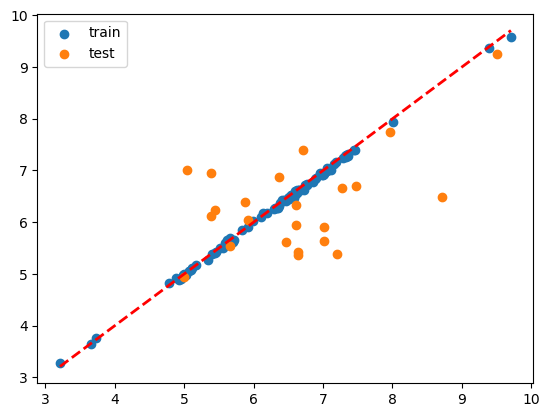

Score Metrics:
Total MSE: 1.6397802
Total MAE: 0.87086403
Total R²: 0.32406514530835573 



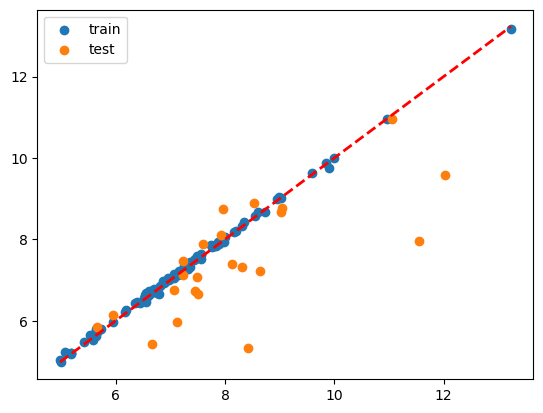

Score Metrics:
Total MSE: 0.818266
Total MAE: 0.6605318
Total R²: 0.8384830960351668 



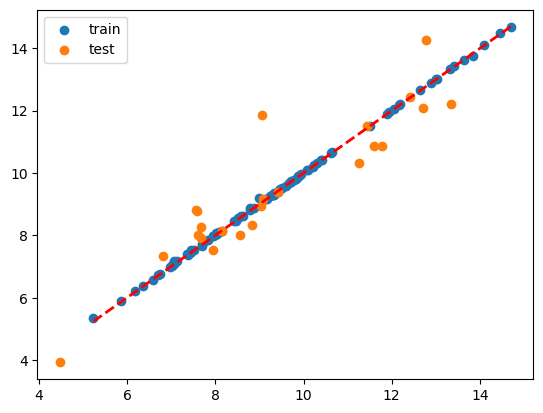

Score Metrics:
Total MSE: 336.62482
Total MAE: 14.76114
Total R²: -0.3961061333089382 



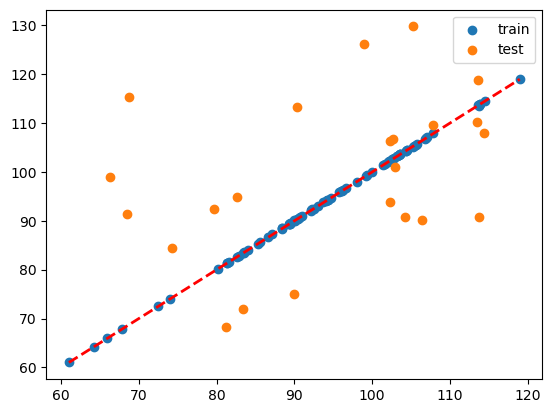

Score Metrics:
Total MSE: 342.47205
Total MAE: 14.739148
Total R²: -0.9171147006845952 



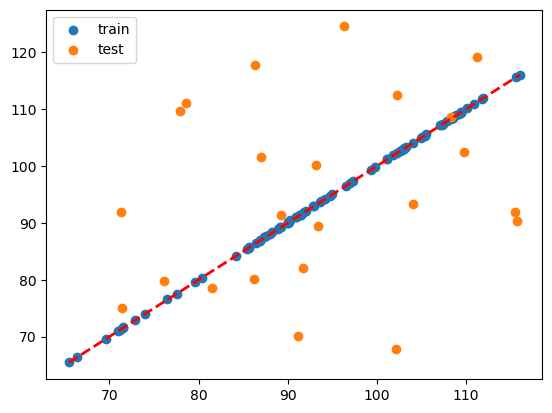

Score Metrics:
Total MSE: 211.60936
Total MAE: 9.553413
Total R²: -0.2068630919439587 



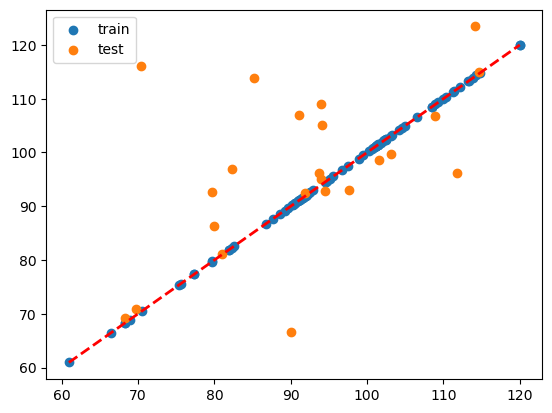

In [207]:
all_predictions, all_true_outputs = pred_model(Triclinicmodel, test_dataset)
all_predictions_train, all_true_outputs_train = pred_model(Triclinicmodel, train_dataset)

eval_plot(all_predictions, all_true_outputs, all_predictions_train, all_true_outputs_train)

In [29]:
# for i in range(6):
#     mse_total = mean_squared_error(all_true_outputs[:, i], all_predictions[:, i])
#     mae_total = mean_absolute_error(all_true_outputs[:, i], all_predictions[:, i])
#     r2_total = r2_score(all_true_outputs[:, i], all_predictions[:, i])
    
#     print("Score Metrics:")
#     print("Total MSE:", mse_total)
#     print("Total MAE:", mae_total)
#     print("Total R²:", r2_total, "\n")

In [30]:
# for i, j in zip(all_predictions, all_true_outputs):
#     print(f"prediction: {i.tolist()}")
#     print(f"True: {j.tolist()}")
#     print()

### Monoclinic

In [209]:
Monoclinic_mask = np.isin(SPACEGROUPNUMBER, ranges["Monoclinic"])
Monoclinic_REPRESENTATION = np.array(REPRESENTATION)[Monoclinic_mask].tolist()
Monoclinic_PARAMS = np.array(PARAMS)[Monoclinic_mask].tolist()

Monoclinic = grouped_data["Monoclinic"]
Monoclinic_REPRESENTATION.extend(Monoclinic['string'])
Monoclinic_PARAMS.extend(Monoclinic['lattice_params'])

In [210]:
Monoclinic_df = pd.DataFrame({"string": Monoclinic_REPRESENTATION, "lattice_params": Monoclinic_PARAMS})
Monoclinic_df['tokens'] = Monoclinic_df['string'].apply(process_string)
Monoclinic_df['tokens'] = Monoclinic_df['tokens'].apply(split_float_values)

token_to_number_combined, number_to_token_combined = VocabDict(Monoclinic_df['tokens'])
vocab_size = len(token_to_number_combined)+1
Monoclinic_df['tokenized'] = Monoclinic_df['tokens'].apply(tokenize_string)

In [211]:
test_X, test_y, remaining_X, remaining_Y, max_sequence_len = preprocess_data(
    Monoclinic_df, 
    RandomGen_len=np.sum(Monoclinic_mask), 
    Target=(0,1,2,4)
)

torch.Size([2, 561]) torch.Size([830, 561])
torch.Size([2, 4]) torch.Size([830, 4])


In [212]:
emb_dim = 32
hidden_size = 64
batch_size=128

In [213]:
train_size = int(0.8 * len(remaining_X))
test_size = len(remaining_X) - train_size
test_dataset2 = TensorDataset(test_X, test_y)
dataset = TensorDataset(remaining_X, remaining_Y)
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [214]:
class MonoclinicModel(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_size, num_layers=3):
        super(MonoclinicModel, self).__init__()
        self.embedding_layer = nn.Embedding(num_embeddings=vocab_size, embedding_dim=emb_dim)
        self.lstm_layer = nn.LSTM(input_size=emb_dim, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.flatten_layer = nn.Flatten()

        self.fc_layers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(in_features=max_sequence_len * hidden_size, out_features=512),
                nn.SiLU(),
                nn.Linear(in_features=512, out_features=128),
                nn.SiLU(),
                nn.Linear(in_features=128, out_features=1)
            )
            for _ in range(4)
        ])

    def forward(self, x):
        # torch.Size([batch_size, max_sequence_len])
        
        embedding = self.embedding_layer(x)
        embedding = F.normalize(embedding, p=2, dim=-1)
        # torch.Size([batch_size, max_sequence_len, emb_dim])
        
        rnn_output, (hidden_state, cell_state) = self.lstm_layer(embedding)
        # torch.Size([batch_size, max_sequence_len, hidden_size])
        
        flattened_output = self.flatten_layer(rnn_output)
        # torch.Size([batch_size, max_sequence_len * hidden_size]

        outputs = [fc(flattened_output) for fc in self.fc_layers]
        final_output = torch.cat(outputs, dim=1)
        # torch.Size([batch_size, 4])
        return final_output

In [215]:
lr=5e-3
wd=1e-5
epochs = 500
num_layers = 3

In [84]:
Monoclinicmodel = MonoclinicModel(vocab_size=vocab_size, emb_dim=emb_dim, hidden_size=hidden_size, num_layers=num_layers).to(device)
criterion = nn.MSELoss(reduction='mean')
optimizer = torch.optim.Adam(Monoclinicmodel.parameters(), lr=lr,weight_decay=wd)
Monoclinicmodel, losses = train_model(Monoclinicmodel, train_loader, criterion, optimizer, epochs)

Epoch 50/500, Loss: 37.0539, Time: 5.6635
Epoch 100/500, Loss: 13.3371, Time: 11.3339
Epoch 150/500, Loss: 1.1463, Time: 17.0563
Epoch 200/500, Loss: 0.1744, Time: 22.8102
Epoch 250/500, Loss: 0.5129, Time: 28.5650
Epoch 300/500, Loss: 0.1096, Time: 34.3425
Epoch 350/500, Loss: 0.7235, Time: 40.1135
Epoch 400/500, Loss: 0.2881, Time: 45.8953
Epoch 450/500, Loss: 2.2521, Time: 51.6765
Epoch 500/500, Loss: 0.0150, Time: 57.4658


In [79]:
# plt.plot(losses)
# plt.ylim(0,3)
# plt.show()

In [216]:
# torch.save(Monoclinicmodel, f'/home/qfu1/TrainedModels/LatticePara/Monoclinicmodel_lr{lr}_wd{wd}_ep{epochs}_nl{num_layers}_bc{batch_size}.pth')
Monoclinicmodel = torch.load(f'/home/qfu1/TrainedModels/LatticePara/Monoclinicmodel_lr{lr}_wd{wd}_ep{epochs}_nl{num_layers}_bc{batch_size}.pth',weights_only=False)

In [217]:
def pred_model(model, test_dataset):
    all_predictions = []
    all_true_outputs = []
    model.eval()
    with torch.no_grad():
        for Input, TrueOutput in test_dataset:
            Input = Input.to(device)
            PredictedOutput = model(Input.unsqueeze(0))

            all_predictions.append(PredictedOutput[0].cpu())
            all_true_outputs.append(TrueOutput)
    
    all_true_outputs = torch.tensor(np.array(all_true_outputs))
    all_predictions = torch.tensor(np.array(all_predictions))
    return all_predictions, all_true_outputs

Score Metrics:
Total MSE: 1.70
Total MAE: 0.58
Total R²: 0.74

Saved plot as pic/plot_0.png


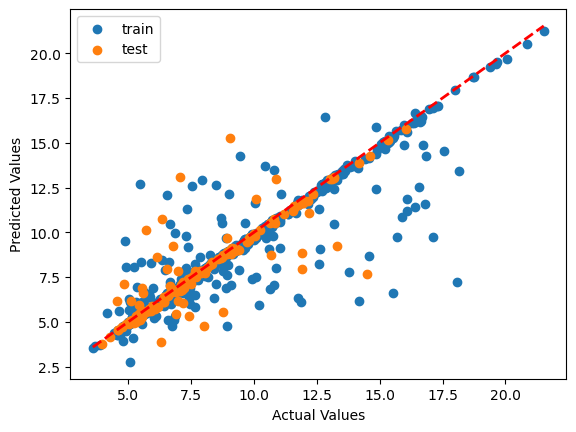

Score Metrics:
Total MSE: 2.35
Total MAE: 0.58
Total R²: 0.82

Saved plot as pic/plot_1.png


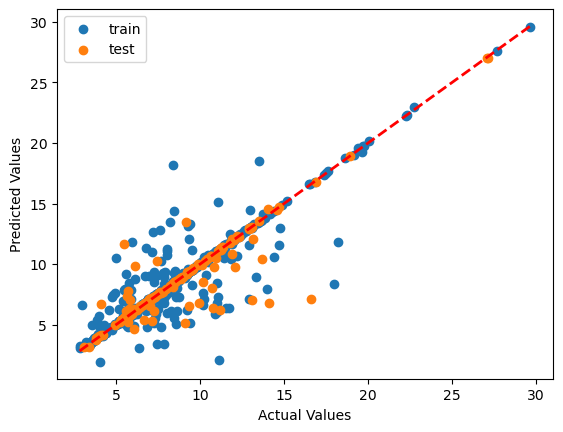

Score Metrics:
Total MSE: 3.30
Total MAE: 0.63
Total R²: 0.67

Saved plot as pic/plot_2.png


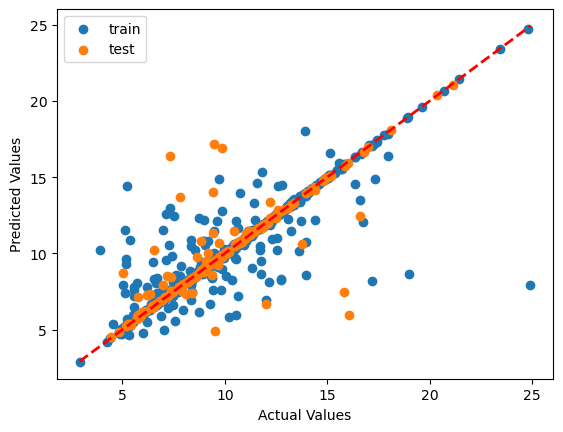

Score Metrics:
Total MSE: 42.09
Total MAE: 2.42
Total R²: 0.71

Saved plot as pic/plot_3.png


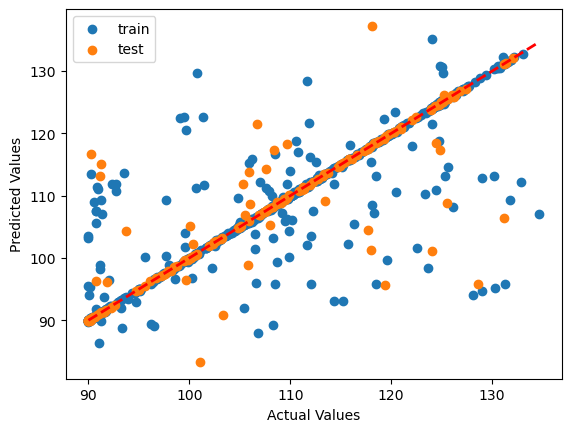

In [222]:
all_predictions, all_true_outputs = pred_model(Monoclinicmodel, test_dataset)
all_predictions_train, all_true_outputs_train = pred_model(Monoclinicmodel, train_dataset)

eval_plot(all_predictions, all_true_outputs, all_predictions_train, all_true_outputs_train, save=True)

In [66]:
# for i, j in zip(all_predictions, all_true_outputs):
#     print(f"True: {j.tolist()}")
#     print(f"prediction: {i.tolist()}")
#     print()

In [67]:
MonoclinicPREDICTIONS = []

Monoclinicmodel.eval()
with torch.no_grad():
    for Input, _ in test_dataset2:
        Input = Input.to(device)
        PredictedOutput = Monoclinicmodel(Input.unsqueeze(0))
        MonoclinicPREDICTIONS.append(PredictedOutput[0].cpu())

MonoclinicPREDICTIONS = [[float(i[0]),float(i[1]),float(i[2]),float(90),float(i[3]),float(90)] for i in MonoclinicPREDICTIONS]


In [68]:
MonoclinicPREDICTIONS

[[7.609729290008545,
  7.4616007804870605,
  9.271186828613281,
  90.0,
  108.01225280761719,
  90.0],
 [7.564321994781494,
  7.2467780113220215,
  8.98334789276123,
  90.0,
  107.92652893066406,
  90.0]]

In [178]:
for idx, i in enumerate(MonoclinicPREDICTIONS):
    PREDICTIONS[Monoclinic_df["string"][idx]] = i   

### Orthorhombic

In [126]:
from crystring.spacegroup import get_cell_param_from_spacegroup
print(get_cell_param_from_spacegroup(grouped_data["Orthorhombic"]["space_group_number"].iloc[0]))

['a' 'b' 'c' '90' '90' '90']


In [127]:
Orthorhombic_mask = np.isin(SPACEGROUPNUMBER, ranges["Orthorhombic"])
Orthorhombic_REPRESENTATION = np.array(REPRESENTATION)[Orthorhombic_mask].tolist()
Orthorhombic_PARAMS = np.array(PARAMS)[Orthorhombic_mask].tolist()

Orthorhombic = grouped_data["Orthorhombic"]
Orthorhombic_REPRESENTATION.extend(Orthorhombic['string'])
Orthorhombic_PARAMS.extend(Orthorhombic['lattice_params'])

In [128]:
Orthorhombic_df = pd.DataFrame({"string": Orthorhombic_REPRESENTATION, "lattice_params": Orthorhombic_PARAMS})
Orthorhombic_df['tokens'] = Orthorhombic_df['string'].apply(process_string)
Orthorhombic_df['tokens'] = Orthorhombic_df['tokens'].apply(split_float_values)

token_to_number_combined, number_to_token_combined = VocabDict(Orthorhombic_df['tokens'])
vocab_size = len(token_to_number_combined)+1
Orthorhombic_df['tokenized'] = Orthorhombic_df['tokens'].apply(tokenize_string)
Orthorhombic_df.head()

,string,lattice_params,tokens,tokenized
0,P c c m Be 2d 0.000 0.000 0.000,"[0, 0, 0, 0, 0, 0]","[START, P, c, c, m, Be, 2d, 0, 0, 0, 0, 0, 0, ...","[15, 17, 22, 22, 14, 135, 101, 1, 1, 1, 1, 1, ..."
1,P m c 21 Zr 4c 0.845 0.092 0.386,"[0, 0, 0, 0, 0, 0]","[START, P, m, c, 21, Zr, 4c, 8, 4, 5, 0, 9, 2,...","[15, 17, 14, 22, 27, 114, 11, 10, 8, 7, 1, 9, ..."
2,P n m a B 4c 0.469 0.000 0.087,"[0, 0, 0, 0, 0, 0]","[START, P, n, m, a, B, 4c, 4, 6, 9, 0, 0, 0, 0...","[15, 17, 20, 14, 19, 47, 11, 8, 4, 9, 1, 1, 1,..."
3,P 21 21 2 V 2a 0.000 0.000 0.465 Gd 2b 0.000 0...,"[0, 0, 0, 0, 0, 0]","[START, P, 21, 21, 2, V, 2a, 0, 0, 0, 0, 0, 0,...","[15, 17, 27, 27, 84, 60, 29, 1, 1, 1, 1, 1, 1,..."
4,P n n a Re 4d 0.184 0.000 0.000,"[0, 0, 0, 0, 0, 0]","[START, P, n, n, a, Re, 4d, 1, 8, 4, 0, 0, 0, ...","[15, 17, 20, 20, 19, 134, 50, 5, 10, 8, 1, 1, ..."


In [129]:
test_X, test_y, remaining_X, remaining_Y, max_sequence_len = preprocess_data(
    Orthorhombic_df, 
    RandomGen_len=np.sum(Orthorhombic_mask), 
    Target=[0,1,2]
)

torch.Size([9, 613]) torch.Size([1233, 613])
torch.Size([9, 3]) torch.Size([1233, 3])


In [130]:
emb_dim = 32
hidden_size = 64
batch_size=128

In [131]:
train_size = int(0.8 * len(remaining_X))
test_size = len(remaining_X) - train_size
test_dataset2 = TensorDataset(test_X, test_y)
dataset = TensorDataset(remaining_X, remaining_Y)
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [132]:
class OrthorhombicModel(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_size, num_layers=3):
        super(OrthorhombicModel, self).__init__()
        self.embedding_layer = nn.Embedding(num_embeddings=vocab_size, embedding_dim=emb_dim)
        self.lstm_layer = nn.LSTM(input_size=emb_dim, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.flatten_layer = nn.Flatten()

        self.fc_layers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(in_features=max_sequence_len * hidden_size, out_features=512),
                nn.SiLU(),
                nn.Linear(in_features=512, out_features=128),
                nn.SiLU(),
                nn.Linear(in_features=128, out_features=1)
            )
            for _ in range(3)
        ])

    def forward(self, x):
        # torch.Size([batch_size, max_sequence_len])
        
        embedding = self.embedding_layer(x)
        embedding = F.normalize(embedding, p=2, dim=-1)
        # torch.Size([batch_size, max_sequence_len, emb_dim])
        
        rnn_output, (hidden_state, cell_state) = self.lstm_layer(embedding)
        # torch.Size([batch_size, max_sequence_len, hidden_size])
        
        flattened_output = self.flatten_layer(rnn_output)
        # torch.Size([batch_size, max_sequence_len * hidden_size]

        outputs = [fc(flattened_output) for fc in self.fc_layers]
        final_output = torch.cat(outputs, dim=1)
        # torch.Size([batch_size, 3])
        return final_output

In [133]:
lr=5e-3
wd=1e-5
epochs = 500
num_layers = 3

In [57]:
Orthorhombicmodel = OrthorhombicModel(vocab_size=vocab_size, emb_dim=emb_dim, hidden_size=hidden_size, num_layers=num_layers)
criterion = nn.MSELoss(reduction='mean')
optimizer = torch.optim.Adam(Orthorhombicmodel.parameters(), lr=lr,weight_decay=wd)
Orthorhombicmodel, losses = train_model(Orthorhombicmodel, train_loader, criterion, optimizer, epochs)

Epoch 50/500, Loss: 2.9888, Time: 7.0124
Epoch 100/500, Loss: 0.5248, Time: 14.0428
Epoch 150/500, Loss: 0.0768, Time: 21.0961
Epoch 200/500, Loss: 0.0280, Time: 28.1878
Epoch 250/500, Loss: 0.0495, Time: 35.2932
Epoch 300/500, Loss: 0.0442, Time: 42.3786
Epoch 350/500, Loss: 0.2133, Time: 49.4989
Epoch 400/500, Loss: 0.0038, Time: 56.6460
Epoch 450/500, Loss: 0.0292, Time: 63.8315
Epoch 500/500, Loss: 0.0187, Time: 71.0378


In [134]:
# torch.save(Orthorhombicmodel, f'/home/qfu1/TrainedModels/LatticePara/Orthorhombicmodel_lr{lr}_wd{wd}_ep{epochs}_nl{num_layers}_bc{batch_size}.pth')
Orthorhombicmodel = torch.load(f'/home/qfu1/TrainedModels/LatticePara/Orthorhombicmodel_lr{lr}_wd{wd}_ep{epochs}_nl{num_layers}_bc{batch_size}.pth',weights_only=False)

Score Metrics:
Total MSE: 0.25499216
Total MAE: 0.23351121
Total R²: 0.9408455016172176 



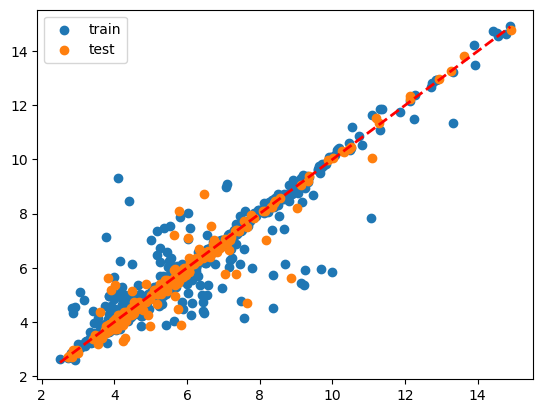

Score Metrics:
Total MSE: 0.82957107
Total MAE: 0.33801338
Total R²: 0.9478706330936354 



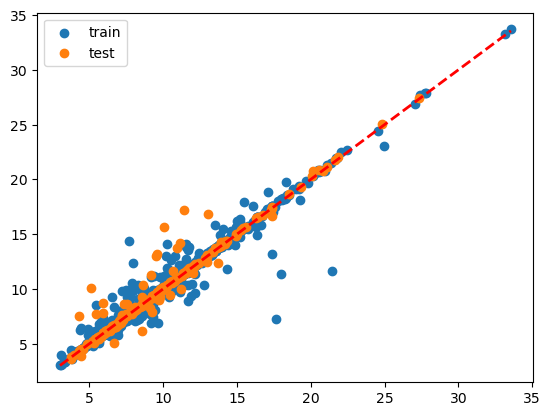

Score Metrics:
Total MSE: 0.8598056
Total MAE: 0.34872288
Total R²: 0.960417660873039 



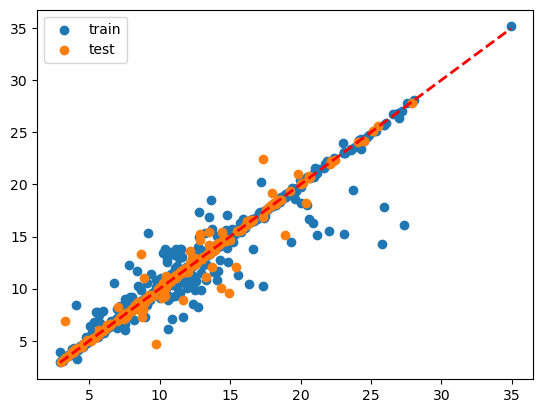

In [137]:
all_predictions, all_true_outputs = pred_model(Orthorhombicmodel, test_dataset)
all_predictions_train, all_true_outputs_train = pred_model(Orthorhombicmodel, train_dataset)

eval_plot(all_predictions, all_true_outputs, all_predictions_train, all_true_outputs_train)

In [61]:
OrthorhombicPREDICTIONS = []

Orthorhombicmodel.eval()
with torch.no_grad():
    for Input, _ in test_dataset2:
        Input = Input.to(device)
        PredictedOutput = Orthorhombicmodel(Input.unsqueeze(0))
        PredictedOutput = PredictedOutput[0].cpu()
        OrthorhombicPREDICTIONS.append([float(PredictedOutput[0]),float(PredictedOutput[1]),float(PredictedOutput[2]),float(90),float(90),float(90)])

OrthorhombicPREDICTIONS

[[4.240314483642578, 4.779841899871826, 4.2294087409973145, 90.0, 90.0, 90.0],
 [4.644141674041748, 6.660783290863037, 6.860330104827881, 90.0, 90.0, 90.0],
 [3.204453945159912, 4.708932876586914, 4.565932750701904, 90.0, 90.0, 90.0],
 [2.825265884399414, 3.912990093231201, 5.334544658660889, 90.0, 90.0, 90.0],
 [3.8024168014526367, 4.527542591094971, 6.845947742462158, 90.0, 90.0, 90.0],
 [3.532869815826416, 4.046518802642822, 2.8192005157470703, 90.0, 90.0, 90.0],
 [3.983442783355713, 6.848045825958252, 5.129321575164795, 90.0, 90.0, 90.0],
 [4.303452491760254, 5.003449440002441, 8.033369064331055, 90.0, 90.0, 90.0],
 [4.276932716369629, 5.157973289489746, 4.318406105041504, 90.0, 90.0, 90.0]]

In [62]:
for idx, i in enumerate(OrthorhombicPREDICTIONS):
    PREDICTIONS[Orthorhombic_df["string"][idx]] = i   

### Tetragonal

In [140]:
from crystring.spacegroup import get_cell_param_from_spacegroup
print(get_cell_param_from_spacegroup(grouped_data["Tetragonal"]["space_group_number"].iloc[0]))

['a' 'a' 'c' '90' '90' '90']


In [141]:
Tetragonal_mask = np.isin(SPACEGROUPNUMBER, ranges["Tetragonal"])
Tetragonal_REPRESENTATION = np.array(REPRESENTATION)[Tetragonal_mask].tolist()
Tetragonal_PARAMS = np.array(PARAMS)[Tetragonal_mask].tolist()

Tetragonal = grouped_data["Tetragonal"]
Tetragonal_REPRESENTATION.extend(Tetragonal['string'])
Tetragonal_PARAMS.extend(Tetragonal['lattice_params'])

In [142]:
Tetragonal_df = pd.DataFrame({"string": Tetragonal_REPRESENTATION, "lattice_params": Tetragonal_PARAMS})
Tetragonal_df['tokens'] = Tetragonal_df['string'].apply(process_string)
Tetragonal_df['tokens'] = Tetragonal_df['tokens'].apply(split_float_values)

token_to_number_combined, number_to_token_combined = VocabDict(Tetragonal_df['tokens'])
vocab_size = len(token_to_number_combined)+1
Tetragonal_df['tokenized'] = Tetragonal_df['tokens'].apply(tokenize_string)
Tetragonal_df.head()

,string,lattice_params,tokens,tokenized
0,P 42/m c m Tl 8l 0.085 0.000 0.000 Cr 2c 0.000...,"[0, 0, 0, 0, 0, 0]","[START, P, 42/m, c, m, Tl, 8l, 0, 8, 5, 0, 0, ...","[12, 19, 69, 29, 8, 133, 150, 1, 4, 10, 1, 1, ..."
1,P 4 n c Mo 8c 0.402 0.620 0.082,"[0, 0, 0, 0, 0, 0]","[START, P, 4, n, c, Mo, 8c, 4, 0, 2, 6, 2, 0, ...","[12, 19, 101, 77, 29, 97, 136, 9, 1, 5, 3, 5, ..."
2,I 41 c d Se 16b 0.804 0.144 0.797,"[0, 0, 0, 0, 0, 0]","[START, I, 41, c, d, Se, 16b, 8, 0, 4, 1, 4, 4...","[12, 15, 102, 29, 35, 61, 161, 4, 1, 9, 6, 9, ..."
3,P 4/n 1 1 Rb 2b 0.000 0.000 0.000 Ti 2a 0.000 ...,"[0, 0, 0, 0, 0, 0]","[START, P, 4/n, 1, 1, Rb, 2b, 0, 0, 0, 0, 0, 0...","[12, 19, 33, 22, 22, 89, 24, 1, 1, 1, 1, 1, 1,..."
4,P 43 1 1 Rh 4a 0.115 0.453 0.101 Fe 4a 0.871 0...,"[0, 0, 0, 0, 0, 0]","[START, P, 43, 1, 1, Rh, 4a, 1, 1, 5, 4, 5, 3,...","[12, 19, 149, 22, 22, 114, 20, 6, 6, 10, 9, 10..."


In [143]:
test_X, test_y, remaining_X, remaining_Y, max_sequence_len = preprocess_data(
    Tetragonal_df, 
    RandomGen_len=np.sum(Tetragonal_mask), 
    Target=[1,2]
)

torch.Size([6, 243]) torch.Size([829, 243])
torch.Size([6, 2]) torch.Size([829, 2])


In [144]:
emb_dim = 32
hidden_size = 64
batch_size=128

In [145]:
train_size = int(0.8 * len(remaining_X))
test_size = len(remaining_X) - train_size
test_dataset2 = TensorDataset(test_X, test_y)
dataset = TensorDataset(remaining_X, remaining_Y)
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [146]:
class TetragonalModel(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_size, num_layers=3):
        super(TetragonalModel, self).__init__()
        self.embedding_layer = nn.Embedding(num_embeddings=vocab_size, embedding_dim=emb_dim)
        self.lstm_layer = nn.LSTM(input_size=emb_dim, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.flatten_layer = nn.Flatten()

        self.fc_layers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(in_features=max_sequence_len * hidden_size, out_features=512),
                nn.SiLU(),
                nn.Linear(in_features=512, out_features=128),
                nn.SiLU(),
                nn.Linear(in_features=128, out_features=1)
            )
            for _ in range(2)
        ])

    def forward(self, x):
        # torch.Size([batch_size, max_sequence_len])
        
        embedding = self.embedding_layer(x)
        embedding = F.normalize(embedding, p=2, dim=-1)
        # torch.Size([batch_size, max_sequence_len, emb_dim])
        
        rnn_output, (hidden_state, cell_state) = self.lstm_layer(embedding)
        # torch.Size([batch_size, max_sequence_len, hidden_size])
        
        flattened_output = self.flatten_layer(rnn_output)
        # torch.Size([batch_size, max_sequence_len * hidden_size]

        outputs = [fc(flattened_output) for fc in self.fc_layers]
        final_output = torch.cat(outputs, dim=1)
        # torch.Size([batch_size, 2])
        return final_output

In [147]:
lr=5e-3
wd=1e-5
epochs = 500
num_layers = 3

In [71]:
Tetragonalmodel = TetragonalModel(vocab_size=vocab_size, emb_dim=emb_dim, hidden_size=hidden_size, num_layers=num_layers).to(device)
criterion = nn.MSELoss(reduction='mean')
optimizer = torch.optim.Adam(Tetragonalmodel.parameters(), lr=lr,weight_decay=wd)
Tetragonalmodel, losses = train_model(Tetragonalmodel, train_loader, criterion, optimizer, epochs)

Epoch 50/500, Loss: 2.3544, Time: 1.8321
Epoch 100/500, Loss: 0.6986, Time: 3.6633
Epoch 150/500, Loss: 0.3511, Time: 5.4960
Epoch 200/500, Loss: 0.1766, Time: 7.3330
Epoch 250/500, Loss: 0.1014, Time: 9.1677
Epoch 300/500, Loss: 0.1699, Time: 10.9986
Epoch 350/500, Loss: 0.0778, Time: 12.8351
Epoch 400/500, Loss: 0.0415, Time: 14.6721
Epoch 450/500, Loss: 0.0925, Time: 16.5090
Epoch 500/500, Loss: 0.0361, Time: 18.3495


In [148]:
# torch.save(Tetragonalmodel, f'/home/qfu1/TrainedModels/LatticePara/Tetragonalmodel_lr{lr}_wd{wd}_ep{epochs}_nl{num_layers}_bc{batch_size}.pth')
Tetragonalmodel = torch.load(f'/home/qfu1/TrainedModels/LatticePara/Tetragonalmodel_lr{lr}_wd{wd}_ep{epochs}_nl{num_layers}_bc{batch_size}.pth',weights_only=False)

Score Metrics:
Total MSE: 0.06250069
Total MAE: 0.13562551
Total R²: 0.9898483415040075 



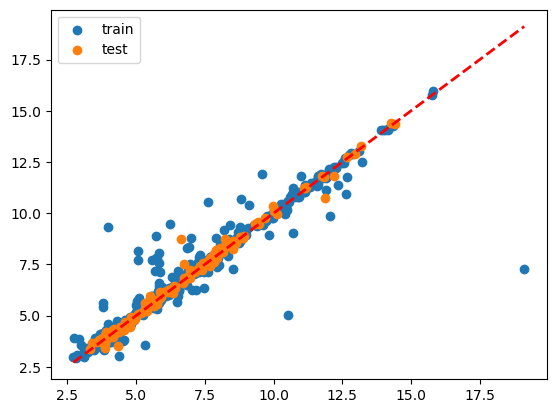

Score Metrics:
Total MSE: 0.16807258
Total MAE: 0.23147316
Total R²: 0.9916283444969157 



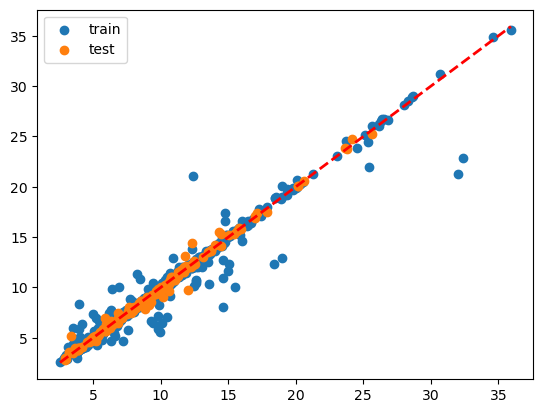

In [149]:
all_predictions, all_true_outputs = pred_model(Tetragonalmodel, test_dataset)
all_predictions_train, all_true_outputs_train = pred_model(Tetragonalmodel, train_dataset)

eval_plot(all_predictions, all_true_outputs, all_predictions_train, all_true_outputs_train)

In [75]:
TetragonalPREDICTIONS = []

Tetragonalmodel.eval()
with torch.no_grad():
    for Input, _ in test_dataset2:
        Input = Input.to(device)
        PredictedOutput = Tetragonalmodel(Input.unsqueeze(0))
        
        TetragonalPREDICTIONS.append(PredictedOutput[0].cpu())
TetragonalPREDICTIONS = [[float(i[0]),float(i[0]),float(i[1]),float(90),float(90),float(90)] for i in TetragonalPREDICTIONS]

In [76]:
for idx, i in enumerate(TetragonalPREDICTIONS):
    PREDICTIONS[Tetragonal_df["string"][idx]] = i   

### Trigonal

In [150]:
Trigonal_mask = np.isin(SPACEGROUPNUMBER, ranges["Trigonal"])
Trigonal_REPRESENTATION = np.array(REPRESENTATION)[Trigonal_mask].tolist()
Trigonal_PARAMS = np.array(PARAMS)[Trigonal_mask].tolist()

Trigonal = grouped_data["Trigonal"]
Trigonal_REPRESENTATION.extend(Trigonal['string'])
Trigonal_PARAMS.extend(Trigonal['lattice_params'])

In [151]:
Trigonal_df = pd.DataFrame({"string": Trigonal_REPRESENTATION, "lattice_params": Trigonal_PARAMS})
Trigonal_df['tokens'] = Trigonal_df['string'].apply(process_string)
Trigonal_df['tokens'] = Trigonal_df['tokens'].apply(split_float_values)

token_to_number_combined, number_to_token_combined = VocabDict(Trigonal_df['tokens'])
vocab_size = len(token_to_number_combined)+1
Trigonal_df['tokenized'] = Trigonal_df['tokens'].apply(tokenize_string)

Trigonal_df.head()

,string,lattice_params,tokens,tokenized
0,P 31 1 2 Tc 6c 0.805 0.765 0.017 N 6c 0.318 0....,"[0, 0, 0, 0, 0, 0]","[START, P, 31, 1, 2, Tc, 6c, 8, 0, 5, 7, 6, 5,...","[13, 23, 79, 11, 49, 136, 15, 2, 1, 7, 4, 6, 7..."
1,R 3 c 1 La 6a 0.000 0.000 0.503 Rn 6a 0.000 0....,"[0, 0, 0, 0, 0, 0]","[START, R, 3, c, 1, La, 6a, 0, 0, 0, 0, 0, 0, ...","[13, 18, 33, 27, 11, 80, 35, 1, 1, 1, 1, 1, 1,..."
2,P 3 1 2 Bi 1a 0.000 0.000 0.000 Ti 1c 0.000 0....,"[0, 0, 0, 0, 0, 0]","[START, P, 3, 1, 2, Bi, 1a, 0, 0, 0, 0, 0, 0, ...","[13, 23, 33, 11, 49, 138, 24, 1, 1, 1, 1, 1, 1..."
3,R 3 m 1 Fe 3a 0.000 0.000 0.46 Fe 3a 0.000 0.0...,"[3.0809956014764124, 3.0809956014764124, 37.78...","[START, R, 3, m, 1, Fe, 3a, 0, 0, 0, 0, 0, 0, ...","[13, 18, 33, 20, 11, 55, 17, 1, 1, 1, 1, 1, 1,..."
4,R 3bar c 1 Ca 6a 0.000 0.000 0.000 Pd 6b 0.000...,"[9.29999704888108, 9.29999704888108, 11.211438...","[START, R, 3bar, c, 1, Ca, 6a, 0, 0, 0, 0, 0, ...","[13, 18, 16, 27, 11, 60, 35, 1, 1, 1, 1, 1, 1,..."


In [152]:
test_X, test_y, remaining_X, remaining_Y, max_sequence_len = preprocess_data(
    Trigonal_df, 
    RandomGen_len=np.sum(Trigonal_mask), 
    Target=[1,2]
)

torch.Size([3, 220]) torch.Size([511, 220])
torch.Size([3, 2]) torch.Size([511, 2])


In [153]:
emb_dim = 32
hidden_size = 64
batch_size=128

In [154]:
train_size = int(0.8 * len(remaining_X))
test_size = len(remaining_X) - train_size
test_dataset2 = TensorDataset(test_X, test_y)
dataset = TensorDataset(remaining_X, remaining_Y)
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [155]:
class TrigonalModel(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_size, num_layers=3):
        super(TrigonalModel, self).__init__()
        self.embedding_layer = nn.Embedding(num_embeddings=vocab_size, embedding_dim=emb_dim)
        self.lstm_layer = nn.LSTM(input_size=emb_dim, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.flatten_layer = nn.Flatten()

        self.fc_layers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(in_features=max_sequence_len * hidden_size, out_features=512),
                nn.SiLU(),
                nn.Linear(in_features=512, out_features=128),
                nn.SiLU(),
                nn.Linear(in_features=128, out_features=1)
            )
            for _ in range(2)
        ])

    def forward(self, x):
        # torch.Size([batch_size, max_sequence_len])
        
        embedding = self.embedding_layer(x)
        embedding = F.normalize(embedding, p=2, dim=-1)
        # torch.Size([batch_size, max_sequence_len, emb_dim])
        
        rnn_output, (hidden_state, cell_state) = self.lstm_layer(embedding)
        # torch.Size([batch_size, max_sequence_len, hidden_size])
        
        flattened_output = self.flatten_layer(rnn_output)
        # torch.Size([batch_size, max_sequence_len * hidden_size]

        outputs = [fc(flattened_output) for fc in self.fc_layers]
        final_output = torch.cat(outputs, dim=1)
        # torch.Size([batch_size, 2])
        return final_output

In [156]:
lr=5e-3
wd=1e-5
epochs = 500
num_layers = 3

In [84]:
Trigonalmodel = TrigonalModel(vocab_size=vocab_size, emb_dim=emb_dim, hidden_size=hidden_size, num_layers=num_layers).to(device)
criterion = nn.MSELoss(reduction='mean')
optimizer = torch.optim.Adam(Trigonalmodel.parameters(), lr=lr,weight_decay=wd)
Trigonalmodel, losses = train_model(Trigonalmodel, train_loader, criterion, optimizer, epochs)

Epoch 50/500, Loss: 8.6848, Time: 1.0923
Epoch 100/500, Loss: 2.1682, Time: 2.1851
Epoch 150/500, Loss: 0.7300, Time: 3.2757
Epoch 200/500, Loss: 0.2789, Time: 4.3715
Epoch 250/500, Loss: 0.2124, Time: 5.4690
Epoch 300/500, Loss: 0.2159, Time: 6.5612
Epoch 350/500, Loss: 0.0861, Time: 7.6534
Epoch 400/500, Loss: 0.0951, Time: 8.7456
Epoch 450/500, Loss: 0.3678, Time: 9.8444
Epoch 500/500, Loss: 0.0901, Time: 10.9393


In [158]:
# torch.save(Trigonalmodel, f'/home/qfu1/TrainedModels/LatticePara/Trigonalmodel_lr{lr}_wd{wd}_ep{epochs}_nl{num_layers}_bc{batch_size}.pth')
Trigonalmodel = torch.load(f'/home/qfu1/TrainedModels/LatticePara/Trigonalmodel_lr{lr}_wd{wd}_ep{epochs}_nl{num_layers}_bc{batch_size}.pth',weights_only=False)

Score Metrics:
Total MSE: 0.23746225
Total MAE: 0.20432939
Total R²: 0.9738180374186304 



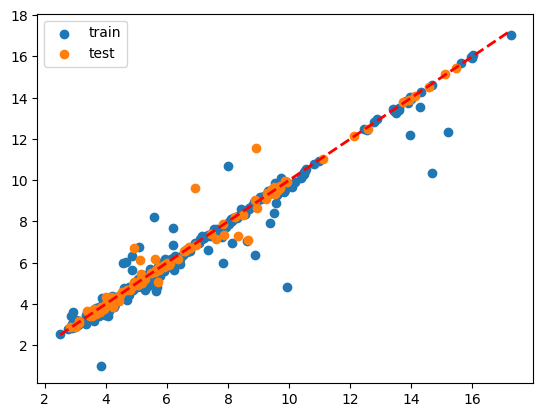

Score Metrics:
Total MSE: 6.700503
Total MAE: 0.660502
Total R²: 0.9225480881305913 



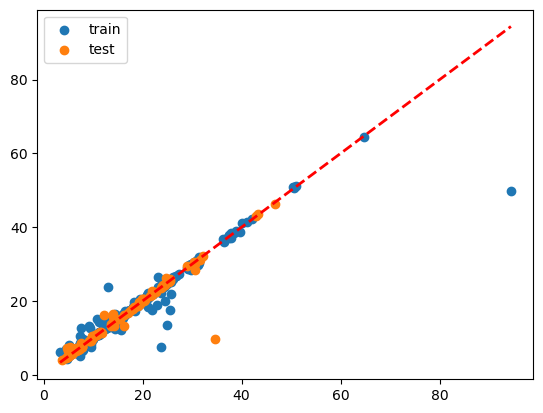

In [159]:
all_predictions, all_true_outputs = pred_model(Trigonalmodel, test_dataset)
all_predictions_train, all_true_outputs_train = pred_model(Trigonalmodel, train_dataset)

eval_plot(all_predictions, all_true_outputs, all_predictions_train, all_true_outputs_train)

In [88]:
TrigonalPREDICTIONS = []

Trigonalmodel.eval()
with torch.no_grad():
    for Input, _ in test_dataset2:
        Input = Input.to(device)
        PredictedOutput = Trigonalmodel(Input.unsqueeze(0))
        TrigonalPREDICTIONS.append(PredictedOutput[0].cpu())
TrigonalPREDICTIONS = [[float(i[0]),float(i[0]),float(i[1]),float(90),float(90),float(120)] for i in TrigonalPREDICTIONS]

In [89]:
for idx, i in enumerate(TrigonalPREDICTIONS):
    PREDICTIONS[Trigonal_df["string"][idx]] = i   

### Hexagonal

In [160]:
from crystring.spacegroup import get_cell_param_from_spacegroup
print(get_cell_param_from_spacegroup(grouped_data["Hexagonal"]["space_group_number"].iloc[0]))

['a' 'a' 'c' '90' '90' '120']


In [161]:
Hexagonal_mask = np.isin(SPACEGROUPNUMBER, ranges["Hexagonal"])
Hexagonal_REPRESENTATION = np.array(REPRESENTATION)[Hexagonal_mask].tolist()
Hexagonal_PARAMS = np.array(PARAMS)[Hexagonal_mask].tolist()

Hexagonal = grouped_data["Hexagonal"]
Hexagonal_REPRESENTATION.extend(Hexagonal['string'])
Hexagonal_PARAMS.extend(Hexagonal['lattice_params'])

In [162]:
Hexagonal_df = pd.DataFrame({"string": Hexagonal_REPRESENTATION, "lattice_params": Hexagonal_PARAMS})
Hexagonal_df['tokens'] = Hexagonal_df['string'].apply(process_string)
Hexagonal_df['tokens'] = Hexagonal_df['tokens'].apply(split_float_values)

token_to_number_combined, number_to_token_combined = VocabDict(Hexagonal_df['tokens'])
vocab_size = len(token_to_number_combined)+1
Hexagonal_df['tokenized'] = Hexagonal_df['tokens'].apply(tokenize_string)
Hexagonal_df.head()

,string,lattice_params,tokens,tokenized
0,P 63/m c m Nb 6g 0.782 0.000 0.000,"[0, 0, 0, 0, 0, 0]","[START, P, 63/m, c, m, Nb, 6g, 7, 8, 2, 0, 0, ...","[10, 12, 20, 15, 13, 76, 34, 9, 3, 2, 1, 1, 1,..."
1,P 6/m m m In 2d 0.000 0.000 0.000 Os 6k 0.235 ...,"[0, 0, 0, 0, 0, 0]","[START, P, 6/m, m, m, In, 2d, 0, 0, 0, 0, 0, 0...","[10, 12, 35, 13, 13, 102, 22, 1, 1, 1, 1, 1, 1..."
2,P 65 1 1 S 6a 0.427 0.229 0.678 Cr 6a 0.763 0....,"[0, 0, 0, 0, 0, 0]","[START, P, 65, 1, 1, S, 6a, 4, 2, 7, 2, 2, 9, ...","[10, 12, 146, 30, 30, 62, 139, 5, 2, 9, 2, 2, ..."
3,P 6bar m 2 W 2i 0.000 0.000 0.811,"[0, 0, 0, 0, 0, 0]","[START, P, 6bar, m, 2, W, 2i, 0, 0, 0, 0, 0, 0...","[10, 12, 26, 13, 23, 125, 127, 1, 1, 1, 1, 1, ..."
4,P 63 c m Po 12d 0.882 0.364 0.724 Mo 2a 0.000 ...,"[0, 0, 0, 0, 0, 0]","[START, P, 63, c, m, Po, 12d, 8, 8, 2, 3, 6, 4...","[10, 12, 31, 15, 13, 150, 108, 3, 3, 2, 7, 6, ..."


In [163]:
test_X, test_y, remaining_X, remaining_Y, max_sequence_len = preprocess_data(
    Hexagonal_df, 
    RandomGen_len=np.sum(Hexagonal_mask), 
    Target=[1,2]
)

torch.Size([6, 331]) torch.Size([676, 331])
torch.Size([6, 2]) torch.Size([676, 2])


In [164]:
emb_dim = 32
hidden_size = 64
batch_size=128

In [165]:
train_size = int(0.8 * len(remaining_X))
test_size = len(remaining_X) - train_size
test_dataset2 = TensorDataset(test_X, test_y)
dataset = TensorDataset(remaining_X, remaining_Y)
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [166]:
class HexagonalModel(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_size, num_layers=3):
        super(HexagonalModel, self).__init__()
        self.embedding_layer = nn.Embedding(num_embeddings=vocab_size, embedding_dim=emb_dim)
        self.lstm_layer = nn.LSTM(input_size=emb_dim, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.flatten_layer = nn.Flatten()

        self.fc_layers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(in_features=max_sequence_len * hidden_size, out_features=512),
                nn.SiLU(),
                nn.Linear(in_features=512, out_features=128),
                nn.SiLU(),
                nn.Linear(in_features=128, out_features=1)
            )
            for _ in range(2)
        ])

    def forward(self, x):
        # torch.Size([batch_size, max_sequence_len])
        
        embedding = self.embedding_layer(x)
        embedding = F.normalize(embedding, p=2, dim=-1)
        # torch.Size([batch_size, max_sequence_len, emb_dim])
        
        rnn_output, (hidden_state, cell_state) = self.lstm_layer(embedding)
        # torch.Size([batch_size, max_sequence_len, hidden_size])
        
        flattened_output = self.flatten_layer(rnn_output)
        # torch.Size([batch_size, max_sequence_len * hidden_size]

        outputs = [fc(flattened_output) for fc in self.fc_layers]
        final_output = torch.cat(outputs, dim=1)
        # torch.Size([batch_size, 2])
        return final_output

In [167]:
lr=5e-3
wd=1e-5
epochs = 500
num_layers = 3

In [168]:
Hexagonalmodel = HexagonalModel(vocab_size=vocab_size, emb_dim=emb_dim, hidden_size=hidden_size, num_layers=num_layers).to(device)
criterion = nn.MSELoss(reduction='mean')
optimizer = torch.optim.Adam(Hexagonalmodel.parameters(), lr=lr,weight_decay=wd)
Hexagonalmodel, losses = train_model(Hexagonalmodel, train_loader, criterion, optimizer, epochs)

Epoch 50/500, Loss: 1.2612, Time: 1.9296
Epoch 100/500, Loss: 0.3402, Time: 3.8607


KeyboardInterrupt: 

In [169]:
# torch.save(Hexagonalmodel, f'/home/qfu1/TrainedModels/LatticePara/Hexagonalmodel_lr{lr}_wd{wd}_ep{epochs}_nl{num_layers}_bc{batch_size}.pth')
Hexagonalmodel = torch.load(f'/home/qfu1/TrainedModels/LatticePara/Hexagonalmodel_lr{lr}_wd{wd}_ep{epochs}_nl{num_layers}_bc{batch_size}.pth',weights_only=False)

Score Metrics:
Total MSE: 0.60157484
Total MAE: 0.3330796
Total R²: 0.9049844803115367 



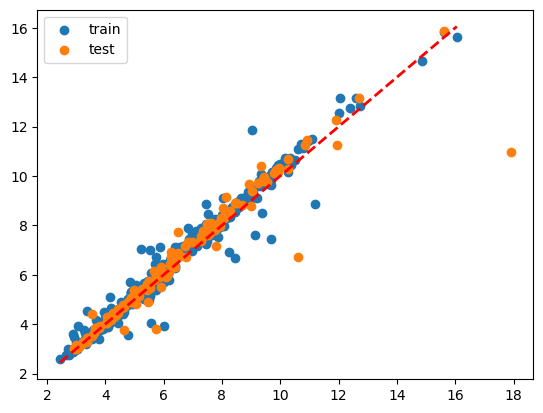

Score Metrics:
Total MSE: 0.8347502
Total MAE: 0.36776504
Total R²: 0.9572252666166139 



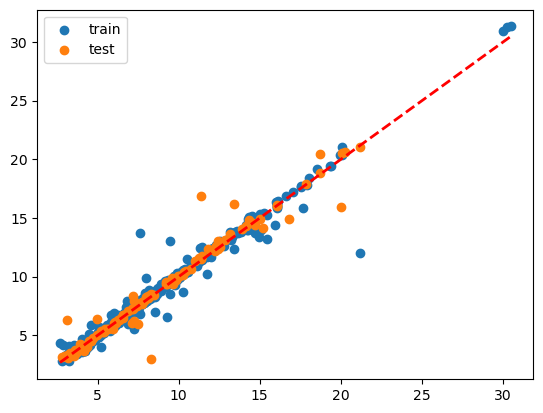

In [170]:
all_predictions, all_true_outputs = pred_model(Hexagonalmodel, test_dataset)
all_predictions_train, all_true_outputs_train = pred_model(Hexagonalmodel, train_dataset)

eval_plot(all_predictions, all_true_outputs, all_predictions_train, all_true_outputs_train)

In [155]:
HexagonalPREDICTIONS = []

Hexagonalmodel.eval()
with torch.no_grad():
    for Input, _ in test_dataset2:
        Input = Input.to(device)
        PredictedOutput = Hexagonalmodel(Input.unsqueeze(0))
        HexagonalPREDICTIONS.append(PredictedOutput[0].cpu())
        
HexagonalPREDICTIONS = [[float(i[0]),float(i[0]),float(i[1]),float(90),float(90),float(120)] for i in HexagonalPREDICTIONS]

In [156]:
HexagonalPREDICTIONS

[[3.5362086296081543,
  3.5362086296081543,
  4.604224681854248,
  90.0,
  90.0,
  120.0],
 [4.704780578613281, 4.704780578613281, 4.467077732086182, 90.0, 90.0, 120.0],
 [8.530006408691406, 8.530006408691406, 5.681811809539795, 90.0, 90.0, 120.0],
 [1.5747886896133423,
  1.5747886896133423,
  4.637090682983398,
  90.0,
  90.0,
  120.0],
 [5.385097026824951, 5.385097026824951, 5.047335147857666, 90.0, 90.0, 120.0],
 [3.677976131439209, 3.677976131439209, 7.132020473480225, 90.0, 90.0, 120.0]]

In [157]:
for idx, i in enumerate(HexagonalPREDICTIONS):
    PREDICTIONS[Hexagonal_df["string"][idx]] = i   

### Cubic

In [171]:
Cubic_mask = np.isin(SPACEGROUPNUMBER, ranges["Cubic"])
Cubic_REPRESENTATION = np.array(REPRESENTATION)[Cubic_mask].tolist()
Cubic_PARAMS = np.array(PARAMS)[Cubic_mask].tolist()

Cubic = grouped_data["Cubic"]
Cubic_REPRESENTATION.extend(Cubic['string'])
Cubic_PARAMS.extend(Cubic['lattice_params'])

In [172]:
Cubic_df = pd.DataFrame({"string": Cubic_REPRESENTATION, "lattice_params": Cubic_PARAMS})
Cubic_df['tokens'] = Cubic_df['string'].apply(process_string)
Cubic_df['tokens'] = Cubic_df['tokens'].apply(split_float_values)

token_to_number_combined, number_to_token_combined = VocabDict(Cubic_df['tokens'])
vocab_size = len(token_to_number_combined)+1
Cubic_df['tokenized'] = Cubic_df['tokens'].apply(tokenize_string)
Cubic_df.head()

,string,lattice_params,tokens,tokenized
0,I 21 3 1 Mo 24c 0.957 0.395 0.369,"[0, 0, 0, 0, 0, 0]","[START, I, 21, 3, 1, Mo, 24c, 9, 5, 7, 3, 9, 5...","[3, 27, 75, 23, 32, 83, 84, 16, 15, 12, 6, 16,..."
1,F 4bar 3 m Pb 4b 0.000 0.000 0.000 Er 16e 0.65...,"[0, 0, 0, 0, 0, 0]","[START, F, 4bar, 3, m, Pb, 4b, 0, 0, 0, 0, 0, ...","[3, 13, 25, 23, 2, 93, 21, 1, 1, 1, 1, 1, 1, 1..."
2,P 4bar 3 n C 6c 0.000 0.000 0.000 In 12g 0.120...,"[0, 0, 0, 0, 0, 0]","[START, P, 4bar, 3, n, C, 6c, 0, 0, 0, 0, 0, 0...","[3, 17, 25, 23, 69, 33, 99, 1, 1, 1, 1, 1, 1, ..."
3,P a 3bar 1 H 24d 0.333 0.931 0.143 Eu 4b 0.000...,"[0, 0, 0, 0, 0, 0]","[START, P, a, 3bar, 1, H, 24d, 3, 3, 3, 9, 3, ...","[3, 17, 53, 5, 32, 164, 30, 6, 6, 6, 16, 6, 8,..."
4,P m 3bar m Ba 1a 0.000 0.000 0.000 Li 1b 0.000...,"[3.98858164, 3.98858164, 3.98858164, 90.0, 90....","[START, P, m, 3bar, m, Ba, 1a, 0, 0, 0, 0, 0, ...","[3, 17, 2, 5, 2, 44, 20, 1, 1, 1, 1, 1, 1, 1, ..."


In [173]:
test_X, test_y, remaining_X, remaining_Y, max_sequence_len = preprocess_data(
    Cubic_df, 
    RandomGen_len=np.sum(Cubic_mask), 
    Target=[0]
)

torch.Size([4, 154]) torch.Size([909, 154])
torch.Size([4, 1]) torch.Size([909, 1])


In [174]:
emb_dim = 32
hidden_size = 64
batch_size=128

In [175]:
train_size = int(0.8 * len(remaining_X))
test_size = len(remaining_X) - train_size
test_dataset2 = TensorDataset(test_X, test_y)
dataset = TensorDataset(remaining_X, remaining_Y)
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [176]:
class CubicModel(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_size, num_layers=3):
        super(CubicModel, self).__init__()
        self.embedding_layer = nn.Embedding(num_embeddings=vocab_size, embedding_dim=emb_dim)
        self.lstm_layer = nn.LSTM(input_size=emb_dim, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.flatten_layer = nn.Flatten()

        self.fc_layers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(in_features=max_sequence_len * hidden_size, out_features=512),
                nn.SiLU(),
                nn.Linear(in_features=512, out_features=128),
                nn.SiLU(),
                nn.Linear(in_features=128, out_features=1)
            )
            for _ in range(1)
        ])

    def forward(self, x):
        # torch.Size([batch_size, max_sequence_len])
        
        embedding = self.embedding_layer(x)
        embedding = F.normalize(embedding, p=2, dim=-1)
        # torch.Size([batch_size, max_sequence_len, emb_dim])
        
        rnn_output, (hidden_state, cell_state) = self.lstm_layer(embedding)
        # torch.Size([batch_size, max_sequence_len, hidden_size])
        
        flattened_output = self.flatten_layer(rnn_output)
        # torch.Size([batch_size, max_sequence_len * hidden_size]

        outputs = [fc(flattened_output) for fc in self.fc_layers]
        final_output = torch.cat(outputs, dim=1)
        # torch.Size([batch_size, 1])
        return final_output

In [177]:
lr=5e-3
wd=1e-5
epochs = 500
num_layers = 3

In [111]:
Cubicmodel = CubicModel(vocab_size=vocab_size, emb_dim=emb_dim, hidden_size=hidden_size, num_layers=num_layers).to(device)
criterion = nn.MSELoss(reduction='mean')
optimizer = torch.optim.Adam(Cubicmodel.parameters(), lr=lr,weight_decay=wd)
Cubicmodel, losses = train_model(Cubicmodel, train_loader, criterion, optimizer, epochs)

Epoch 50/500, Loss: 0.8572, Time: 1.0216
Epoch 100/500, Loss: 0.1591, Time: 2.0572
Epoch 150/500, Loss: 0.0752, Time: 3.0934
Epoch 200/500, Loss: 0.0394, Time: 4.1219
Epoch 250/500, Loss: 0.0246, Time: 5.1480
Epoch 300/500, Loss: 0.0251, Time: 6.1759
Epoch 350/500, Loss: 0.0281, Time: 7.2073
Epoch 400/500, Loss: 0.0121, Time: 8.2350
Epoch 450/500, Loss: 0.0083, Time: 9.2657
Epoch 500/500, Loss: 0.0163, Time: 10.2927


In [178]:
# torch.save(Cubicmodel, f'/home/qfu1/TrainedModels/LatticePara/Cubicmodel_lr{lr}_wd{wd}_ep{epochs}_nl{num_layers}_bc{batch_size}.pth')
Cubicmodel = torch.load(f'/home/qfu1/TrainedModels/LatticePara/Cubicmodel_lr{lr}_wd{wd}_ep{epochs}_nl{num_layers}_bc{batch_size}.pth',weights_only=False)

Score Metrics:
Total MSE: 0.06980573
Total MAE: 0.1163252
Total R²: 0.9910000363157013 



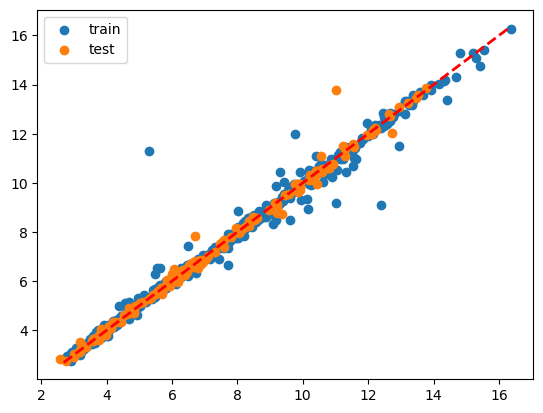

In [179]:
all_predictions, all_true_outputs = pred_model(Cubicmodel, test_dataset)
all_predictions_train, all_true_outputs_train = pred_model(Cubicmodel, train_dataset)

eval_plot(all_predictions, all_true_outputs, all_predictions_train, all_true_outputs_train)

In [115]:
CubicPREDICTIONS = []

Cubicmodel.eval()
with torch.no_grad():
    for Input, _ in test_dataset2:
        Input = Input.to(device)
        PredictedOutput = Cubicmodel(Input.unsqueeze(0))
        CubicPREDICTIONS.append(PredictedOutput)
CubicPREDICTIONS = [[float(i[0]),float(i[0]),float(i[0]),float(90),float(90),float(90)] for i in CubicPREDICTIONS]

In [141]:
CubicPREDICTIONS

[[6.454463005065918, 6.454463005065918, 6.454463005065918, 90.0, 90.0, 90.0],
 [7.937841415405273, 7.937841415405273, 7.937841415405273, 90.0, 90.0, 90.0],
 [6.490604400634766, 6.490604400634766, 6.490604400634766, 90.0, 90.0, 90.0],
 [9.828307151794434, 9.828307151794434, 9.828307151794434, 90.0, 90.0, 90.0]]

In [116]:
for idx, i in enumerate(CubicPREDICTIONS):
    PREDICTIONS[Cubic_df["string"][idx]] = i  

### Generate Cif files

In [180]:
from crystring.representation import get_crystal_structure
from ase.io import write

In [181]:
KEYS = []
for key, value in PREDICTIONS.items():
    unit_cell = {
        "a": value[0],
        "b": value[1],
        "c": value[2],
        "alpha": value[3],
        "beta": value[4],
        "gamma": value[5],
    }
    structure = get_crystal_structure(key, unit_cell, return_basis = False)
    key = key.replace(" ", "_")
    key = key.replace("/", ":")
    KEYS.append(key)
    write(f"/home/qfu1/RandomGenLSTMCellpar_6models/{key}.cif", structure)

In [182]:
df = pd.DataFrame({
    'index': KEYS,
    'prediction': [0]*len(RandomGenDATA)
})

In [184]:
df.to_csv('/home/qfu1/RandomGenLSTMCellpar_6models/id_prop.csv', header=False, index=False)